# Citi Bike & Weather Exploratory Data Analysis
## Midterm Project

Weiyi Lu & Liuyang Bai

In [10]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
import zipfile
import datetime
import statsmodels.api as sm
import statsmodels.formula.api as smf

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## Data Preparing and Preprocessing

In [ ]:
# fetch citi bike data
def fetch_citi(year_month):
    url = f"https://s3.amazonaws.com/tripdata/JC-{year_month}-citibike-tripdata.csv.zip"
    response = requests.get(url)
    # 202510 data has a special form, use an extra statement!
    if response.status_code != 200:
        url = f"https://s3.amazonaws.com/tripdata/JC-{year_month}-citibike-tripdata.zip"
        response = requests.get(url)
    if response.status_code == 200:
        with zipfile.ZipFile(BytesIO(response.content)) as z:
            csv_filename = [f for f in z.namelist() if f.endswith('.csv') and not f.startswith('__MACOSX')][0]
            df = pd.read_csv(z.open(csv_filename), low_memory=False)
            df['started_at'] = pd.to_datetime(df['started_at'])
            return df
    return pd.DataFrame()

dfs = []
for m in range(1, 13):
    print(f"Fetching 2025-{m:02d}...")
    dfs.append(fetch_citi(f"2025{m:02d}"))
df_bike = pd.concat(dfs, ignore_index=True)
df_bike['date'] = df_bike['started_at'].dt.date
df_bike['hour'] = df_bike['started_at'].dt.hour
df_bike['month'] = df_bike['started_at'].dt.month

Fetching 2025-01...
Fetching 2025-02...
Fetching 2025-03...
Fetching 2025-04...
Fetching 2025-05...
Fetching 2025-06...
Fetching 2025-07...
Fetching 2025-08...
Fetching 2025-09...
Fetching 2025-10...
Fetching 2025-11...
Fetching 2025-12...


In [12]:
# fetch weather data
LATITUDE, LONGITUDE = 40.7113, -74.0647
WEATHER_API_URL = "https://archive-api.open-meteo.com/v1/archive"

def get_weather(start, end):
    params = {"latitude": LATITUDE, "longitude": LONGITUDE, "start_date": start, "end_date": end, "hourly": "temperature_2m,precipitation,wind_speed_10m", "timezone": "America/New_York"}
    res = requests.get(WEATHER_API_URL, params=params).json()
    df = pd.DataFrame({"time": pd.to_datetime(res["hourly"]["time"]), "temperature_c": res["hourly"]["temperature_2m"], "precipitation_mm": res["hourly"]["precipitation"], "wind_speed_kmh": res["hourly"]["wind_speed_10m"]})
    df['date'] = df['time'].dt.date
    df['hour'] = df['time'].dt.hour
    return df

weather_df = get_weather("2025-01-01", "2025-12-31")
weather_df['date'] = pd.to_datetime(weather_df['date'])

In [13]:
# data merging
df_bike['date'] = pd.to_datetime(df_bike['date'])
bike_hourly = df_bike.groupby(['date', 'hour']).size().reset_index(name='ride_count')

hourly_df = pd.merge(bike_hourly, weather_df, on=['date', 'hour'], how='inner')
hourly_df['weekday'] = hourly_df['date'].dt.weekday
hourly_df['is_weekend'] = hourly_df['weekday'] >= 5

daily_weather = weather_df.groupby('date').agg({'temperature_c': 'mean','precipitation_mm': 'sum','wind_speed_kmh': 'mean'}).reset_index()
daily_rides = df_bike.groupby('date').size().reset_index(name='ride_count')
daily_df = pd.merge(daily_rides, daily_weather, on='date', how='inner')
daily_df['weekday'] = daily_df['date'].dt.weekday
daily_df['is_weekend'] = daily_df['weekday'] >= 5
daily_df['month'] = daily_df['date'].dt.month

## Basic Data Exploration

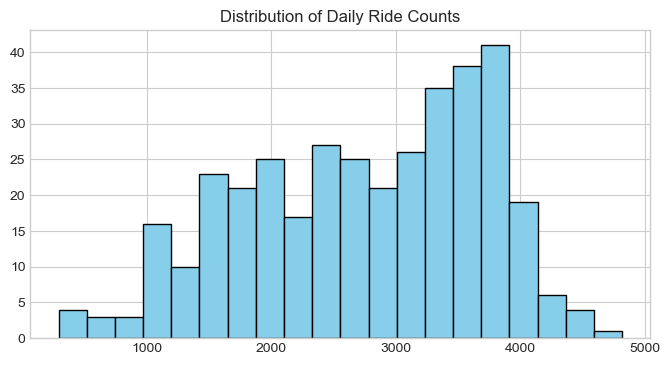

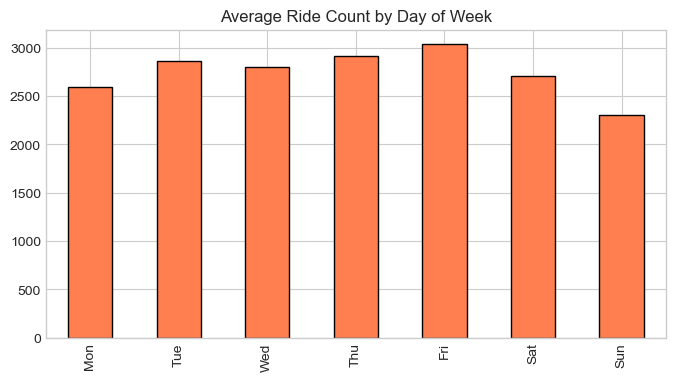

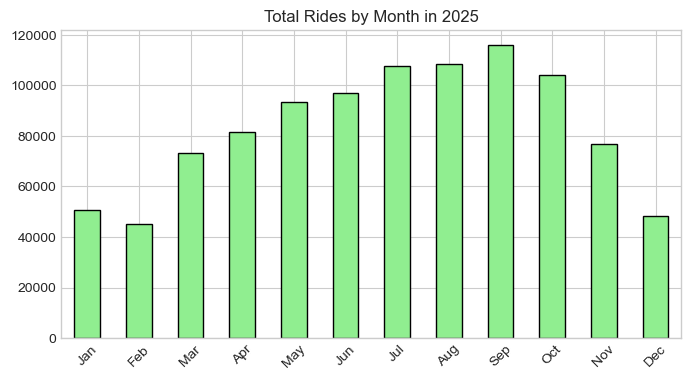

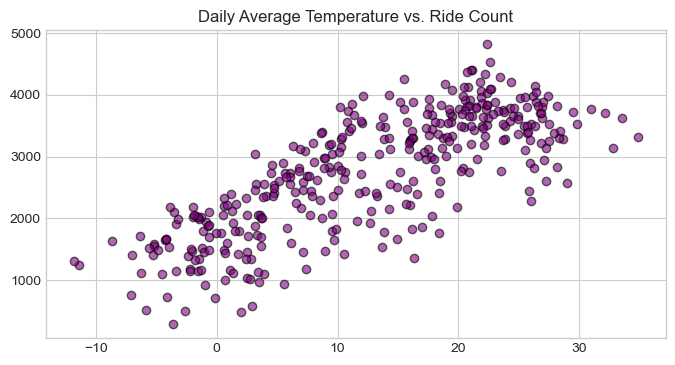

In [14]:
plt.figure(figsize=(8,4))
daily_df['ride_count'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Daily Ride Counts")
plt.show()

plt.figure(figsize=(8,4))
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
avg_rides_by_day = daily_df.groupby('weekday')['ride_count'].mean()
avg_rides_by_day.index = day_order
avg_rides_by_day.plot(kind='bar', color='coral', edgecolor='black')
plt.title("Average Ride Count by Day of Week")
plt.show()

plt.figure(figsize=(8,4))
import calendar
rides_by_month = daily_df.groupby('month')['ride_count'].sum()
rides_by_month.index = [calendar.month_abbr[m] for m in rides_by_month.index]
rides_by_month.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Total Rides by Month in 2025")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(daily_df['temperature_c'], daily_df['ride_count'], alpha=0.6, color='purple', edgecolor='black')
plt.title("Daily Average Temperature vs. Ride Count")
plt.show()

## Weather Overall Impact

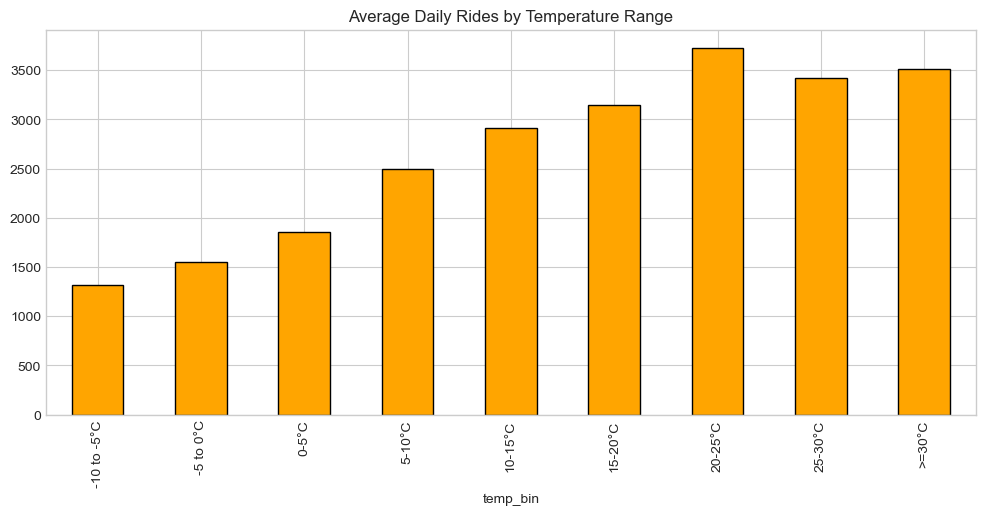

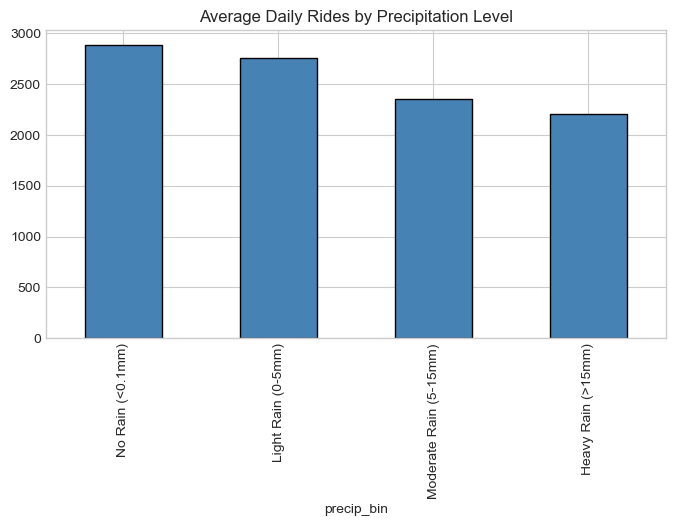

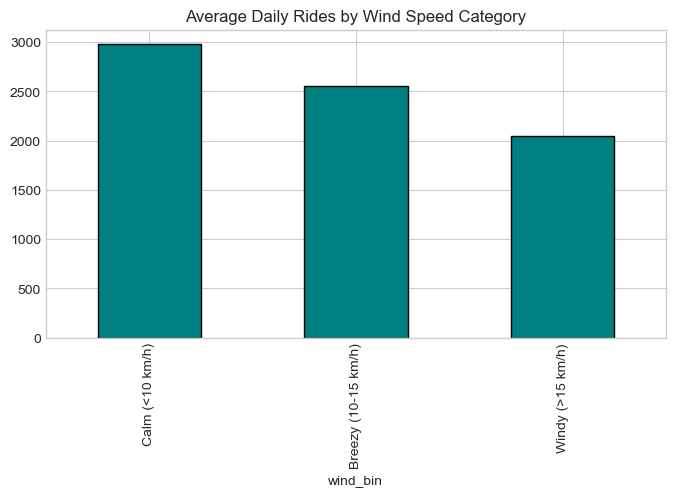

In [15]:
daily_df['temp_bin'] = pd.cut(daily_df['temperature_c'], bins=[-10, -5, 0, 5, 10, 15, 20, 25, 30, 40], labels=['-10 to -5°C', '-5 to 0°C', '0-5°C', '5-10°C', '10-15°C', '15-20°C', '20-25°C', '25-30°C', '>=30°C'])
temp_grouped = daily_df.groupby('temp_bin', observed=False)['ride_count'].mean()
plt.figure(figsize=(12,5))
temp_grouped.plot(kind='bar', color='orange', edgecolor='black')
plt.title("Average Daily Rides by Temperature Range")
plt.show()

daily_df['precip_bin'] = pd.cut(daily_df['precipitation_mm'], bins=[-0.1, 0.1, 5, 15, 100], labels=['No Rain (<0.1mm)', 'Light Rain (0-5mm)', 'Moderate Rain (5-15mm)', 'Heavy Rain (>15mm)'])
precip_grouped = daily_df.groupby('precip_bin', observed=False)['ride_count'].mean()
plt.figure(figsize=(8,4))
precip_grouped.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Average Daily Rides by Precipitation Level")
plt.show()

daily_df['wind_bin'] = pd.cut(daily_df['wind_speed_kmh'], bins=[-1, 10, 15, 100], labels=['Calm (<10 km/h)', 'Breezy (10-15 km/h)', 'Windy (>15 km/h)'])
wind_grouped = daily_df.groupby('wind_bin', observed=False)['ride_count'].mean()
plt.figure(figsize=(8,4))
wind_grouped.plot(kind='bar', color='teal', edgecolor='black')
plt.title("Average Daily Rides by Wind Speed Category")
plt.show()

## Hourly Commute Pattern Analysis

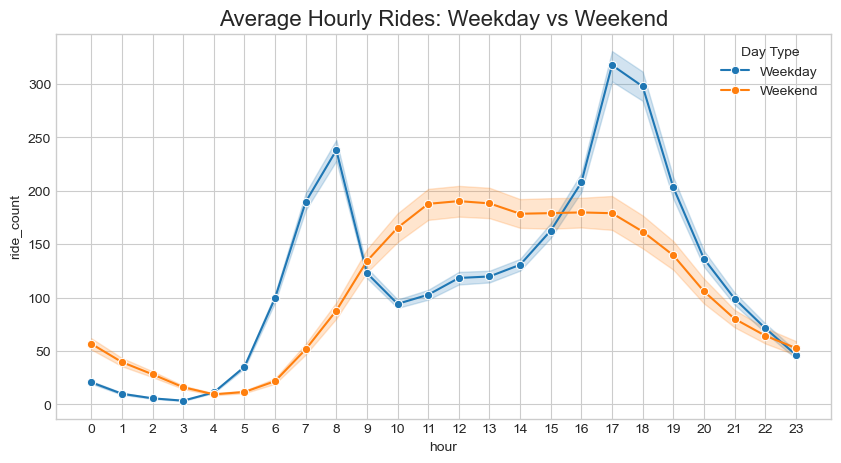

In [16]:
plot_data = hourly_df.copy()
plot_data['Day Type'] = plot_data['is_weekend'].map({False: 'Weekday', True: 'Weekend'})
plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_data, x='hour', y='ride_count', hue='Day Type', marker='o')
plt.xticks(range(24))
plt.title("Average Hourly Rides: Weekday vs Weekend", fontsize=16)
plt.show()

#### 1. Impact of Rain
Examine the effect of rain on hourly ridership, as well as the sensitivity of daily rides to rain.

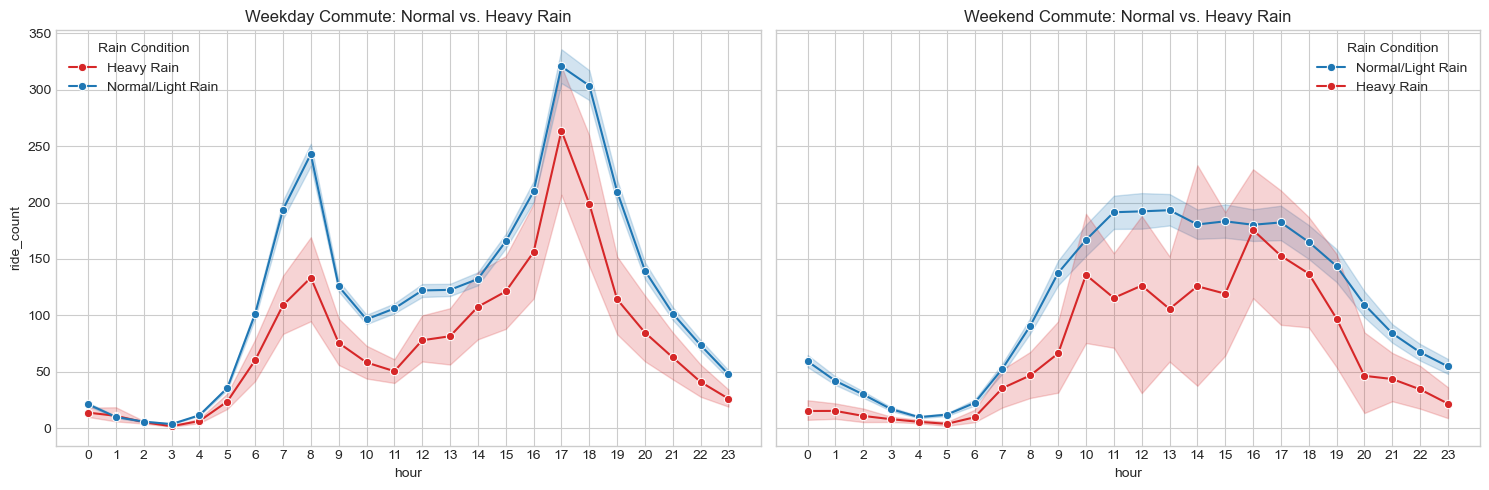

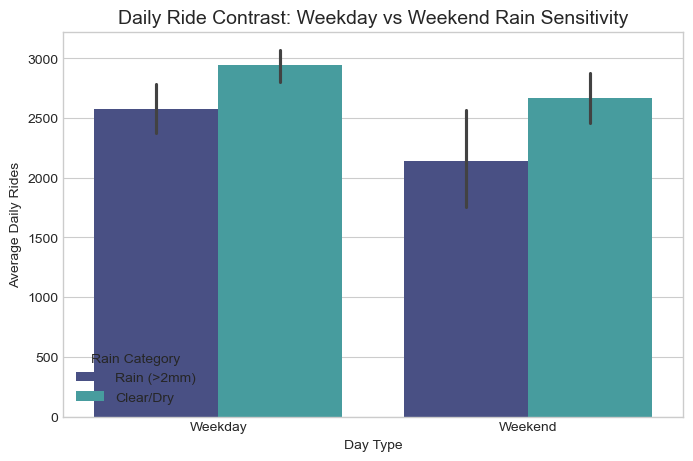

In [17]:
# Calculate thresholds for hourly data
rainy_hours = hourly_df[hourly_df['precipitation_mm'] > 0]['precipitation_mm']
heavy_rain_threshold = rainy_hours.quantile(0.5) if not rainy_hours.empty else 1.0
hourly_df['is_heavy_rain'] = hourly_df['precipitation_mm'] > heavy_rain_threshold

weekdays_hourly = hourly_df[~hourly_df['is_weekend']].copy()
weekdays_hourly['Rain Condition'] = weekdays_hourly['is_heavy_rain'].map({False: 'Normal/Light Rain', True: 'Heavy Rain'})

weekend_hourly = hourly_df[hourly_df['is_weekend']].copy()
weekend_hourly['Rain Condition'] = weekend_hourly['is_heavy_rain'].map({False: 'Normal/Light Rain', True: 'Heavy Rain'})

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Weekday Rain
sns.lineplot(data=weekdays_hourly, x='hour', y='ride_count', hue='Rain Condition', palette=['#d62728','#1f77b4'], marker='o', ax=axes[0])
axes[0].set_title("Weekday Commute: Normal vs. Heavy Rain")
axes[0].set_xticks(range(24))

# Weekend Rain
sns.lineplot(data=weekend_hourly, x='hour', y='ride_count', hue='Rain Condition', palette=['#1f77b4', '#d62728'], marker='o', ax=axes[1])
axes[1].set_title("Weekend Commute: Normal vs. Heavy Rain")
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.show()

# Daily Contrast Plot
daily_df['Rain Category'] = daily_df['precipitation_mm'].apply(lambda x: 'Rain (>2mm)' if x > 2.0 else 'Clear/Dry')
daily_df['Day Type'] = daily_df['is_weekend'].map({False: 'Weekday', True: 'Weekend'})

plt.figure(figsize=(8, 5))
sns.barplot(data=daily_df, x='Day Type', y='ride_count', hue='Rain Category', palette='mako')
plt.title("Daily Ride Contrast: Weekday vs Weekend Rain Sensitivity", fontsize=14)
plt.ylabel("Average Daily Rides")
plt.show()

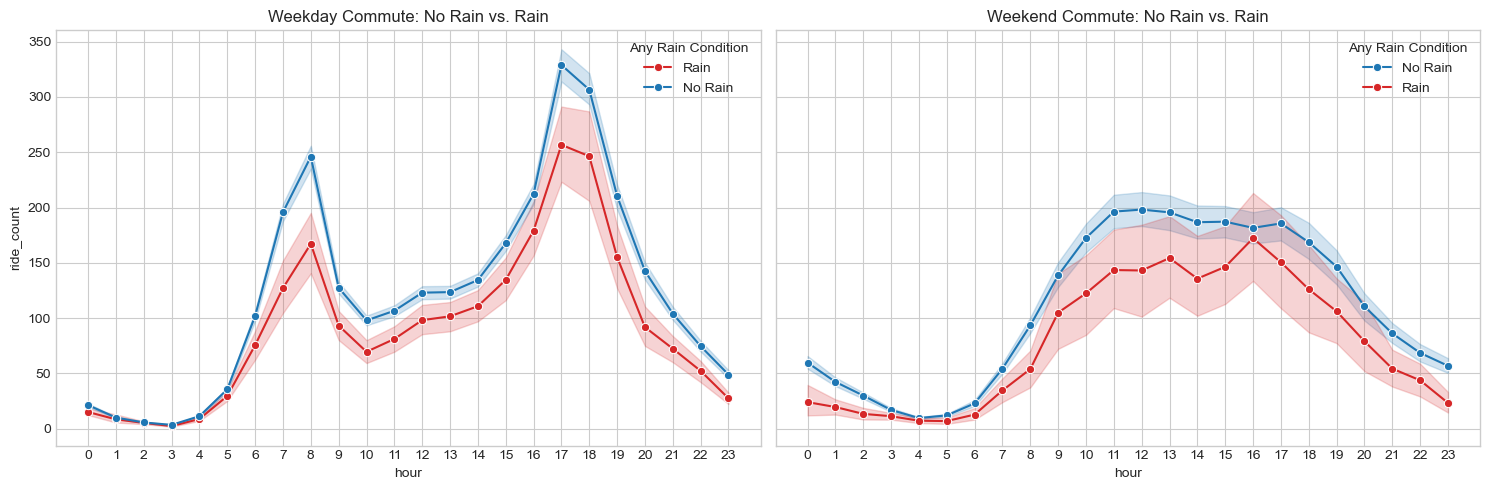

In [18]:
# Any Rain vs No Rain
weekdays_hourly['is_rain'] = weekdays_hourly['precipitation_mm'] > 0
weekdays_hourly['Any Rain Condition'] = weekdays_hourly['is_rain'].map({False: 'No Rain', True: 'Rain'})

weekend_hourly['is_rain'] = weekend_hourly['precipitation_mm'] > 0
weekend_hourly['Any Rain Condition'] = weekend_hourly['is_rain'].map({False: 'No Rain', True: 'Rain'})

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Weekday
sns.lineplot(data=weekdays_hourly, x='hour', y='ride_count', hue='Any Rain Condition', palette=['#d62728', '#1f77b4'], marker='o', ax=axes[0])
axes[0].set_title("Weekday Commute: No Rain vs. Rain")
axes[0].set_xticks(range(24))

# Weekend
sns.lineplot(data=weekend_hourly, x='hour', y='ride_count', hue='Any Rain Condition', palette=['#1f77b4', '#d62728'], marker='o', ax=axes[1])
axes[1].set_title("Weekend Commute: No Rain vs. Rain")
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.show()

#### 2. Impact of Wind
Examine the effect of winds on hourly ridership, as well as the sensitivity of daily rides to wind.

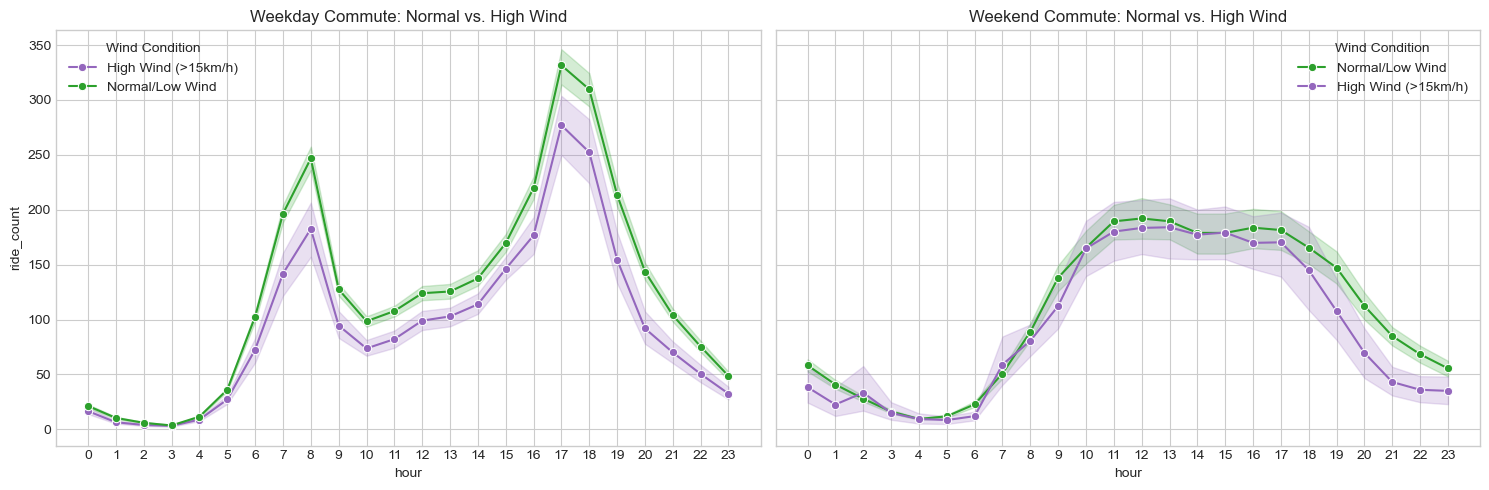

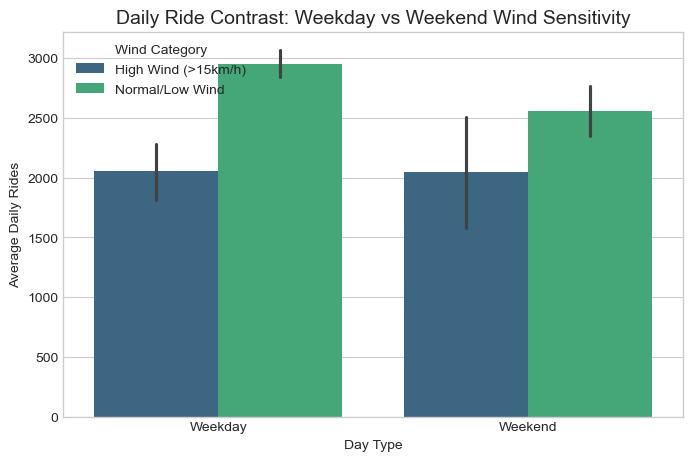

In [19]:
high_wind_threshold = 15.0
weekdays_hourly['Wind Condition'] = weekdays_hourly['wind_speed_kmh'].apply(lambda x: 'High Wind (>15km/h)' if x > high_wind_threshold else 'Normal/Low Wind')
weekend_hourly['Wind Condition'] = weekend_hourly['wind_speed_kmh'].apply(lambda x: 'High Wind (>15km/h)' if x > high_wind_threshold else 'Normal/Low Wind')

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Weekday Wind
sns.lineplot(data=weekdays_hourly, x='hour', y='ride_count', hue='Wind Condition', palette=['#9467bd','#2ca02c'], marker='o', ax=axes[0])
axes[0].set_title("Weekday Commute: Normal vs. High Wind")
axes[0].set_xticks(range(24))

# Weekend Wind
sns.lineplot(data=weekend_hourly, x='hour', y='ride_count', hue='Wind Condition', palette=['#2ca02c', '#9467bd'], marker='o', ax=axes[1])
axes[1].set_title("Weekend Commute: Normal vs. High Wind")
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.show()

# Daily Contrast Plot
daily_df['Wind Category'] = daily_df['wind_speed_kmh'].apply(lambda x: 'High Wind (>15km/h)' if x > 15.0 else 'Normal/Low Wind')

plt.figure(figsize=(8, 5))
sns.barplot(data=daily_df, x='Day Type', y='ride_count', hue='Wind Category', palette='viridis')
plt.title("Daily Ride Contrast: Weekday vs Weekend Wind Sensitivity", fontsize=14)
plt.ylabel("Average Daily Rides")
plt.show()

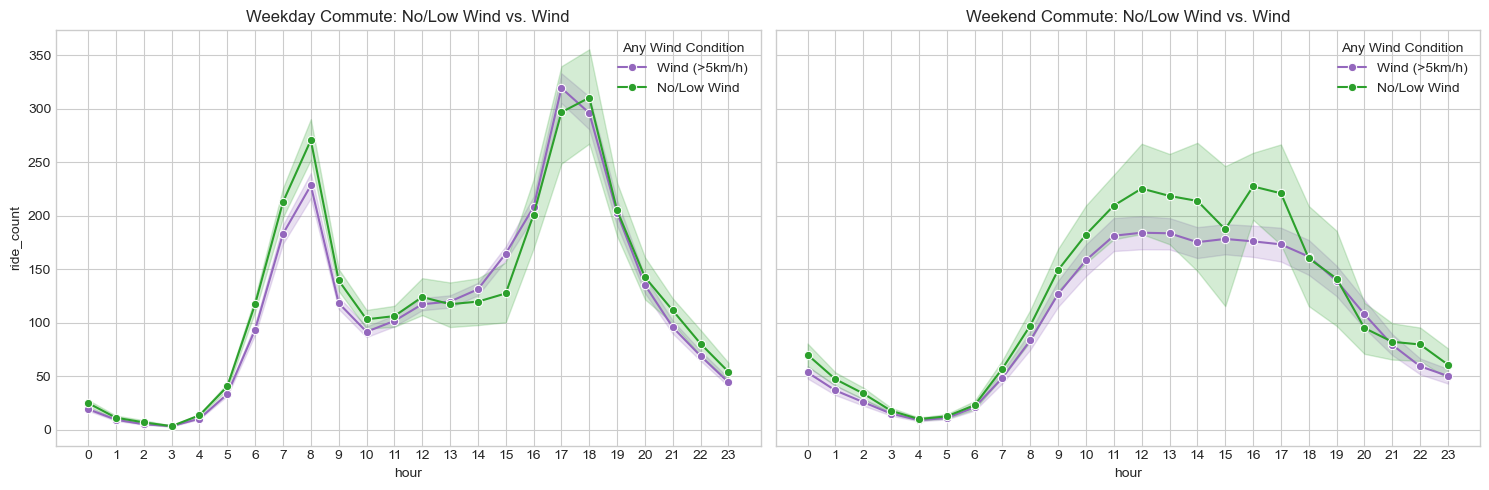

In [20]:
# Wind vs No/low wind
# using 5 km/h as a threshold
windy_threshold = 5.0
weekdays_hourly['Any Wind Condition'] = weekdays_hourly['wind_speed_kmh'].apply(lambda x: 'Wind (>5km/h)' if x > windy_threshold else 'No/Low Wind')
weekend_hourly['Any Wind Condition'] = weekend_hourly['wind_speed_kmh'].apply(lambda x: 'Wind (>5km/h)' if x > windy_threshold else 'No/Low Wind')

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Weekday
sns.lineplot(data=weekdays_hourly, x='hour', y='ride_count', hue='Any Wind Condition', palette=['#9467bd', '#2ca02c'], marker='o', ax=axes[0])
axes[0].set_title("Weekday Commute: No/Low Wind vs. Wind")
axes[0].set_xticks(range(24))

# Weekend
sns.lineplot(data=weekend_hourly, x='hour', y='ride_count', hue='Any Wind Condition', palette=['#9467bd', '#2ca02c'], marker='o', ax=axes[1])
axes[1].set_title("Weekend Commute: No/Low Wind vs. Wind")
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.show()

#### 3. Impact of Temperature
Examine the effect of temperature on hourly ridership, as well as the sensitivity of daily rides to temperature.

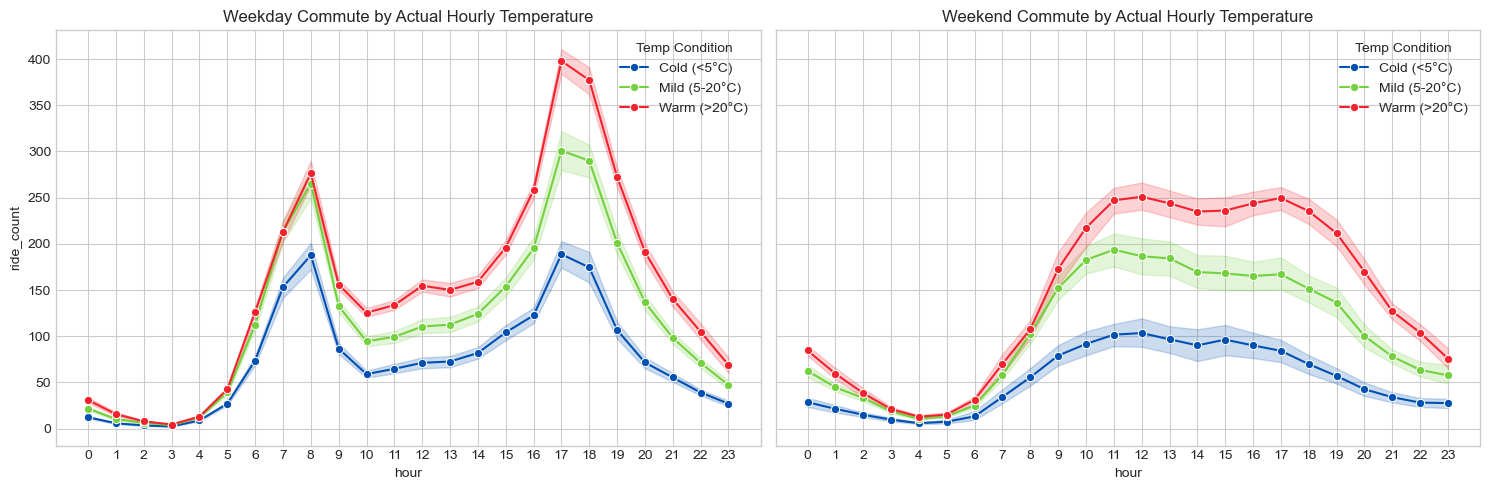

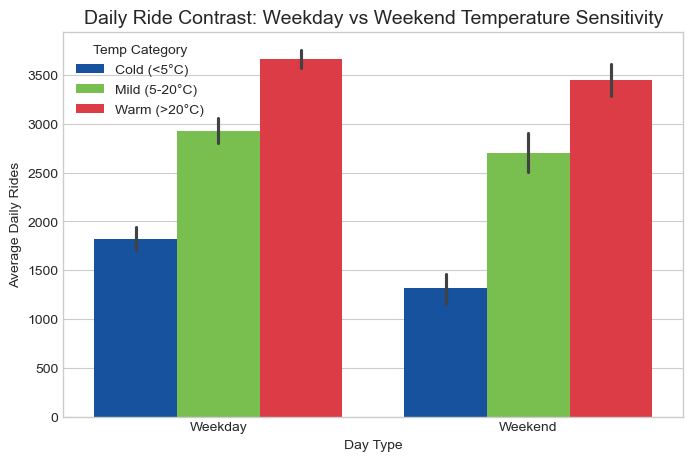

In [21]:
# Bins for hourly temperature
temp_bins = [-20, 5, 20, 50]
temp_labels = ['Cold (<5°C)', 'Mild (5-20°C)', 'Warm (>20°C)']
weekdays_hourly['Temp Condition'] = pd.cut(weekdays_hourly['temperature_c'], bins=temp_bins, labels=temp_labels)
weekend_hourly['Temp Condition'] = pd.cut(weekend_hourly['temperature_c'], bins=temp_bins, labels=temp_labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Weekday Temp
sns.lineplot(data=weekdays_hourly, x='hour', y='ride_count', hue='Temp Condition', palette=["#0050B3", "#73D13D", "#F5222D"], marker='o', ax=axes[0])
axes[0].set_title("Weekday Commute by Actual Hourly Temperature")
axes[0].set_xticks(range(24))

# Weekend Temp
sns.lineplot(data=weekend_hourly, x='hour', y='ride_count', hue='Temp Condition', palette=["#0050B3", "#73D13D", "#F5222D"], marker='o', ax=axes[1])
axes[1].set_title("Weekend Commute by Actual Hourly Temperature")
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.show()

# Daily Contrast Plot
daily_df['Temp Category'] = pd.cut(daily_df['temperature_c'], bins=temp_bins, labels=temp_labels)

plt.figure(figsize=(8, 5))
sns.barplot(data=daily_df, x='Day Type', y='ride_count', hue='Temp Category', palette=["#0050B3", "#73D13D", "#F5222D"])
plt.title("Daily Ride Contrast: Weekday vs Weekend Temperature Sensitivity", fontsize=14)
plt.ylabel("Average Daily Rides")
plt.show()

#### 4. Member vs Casual

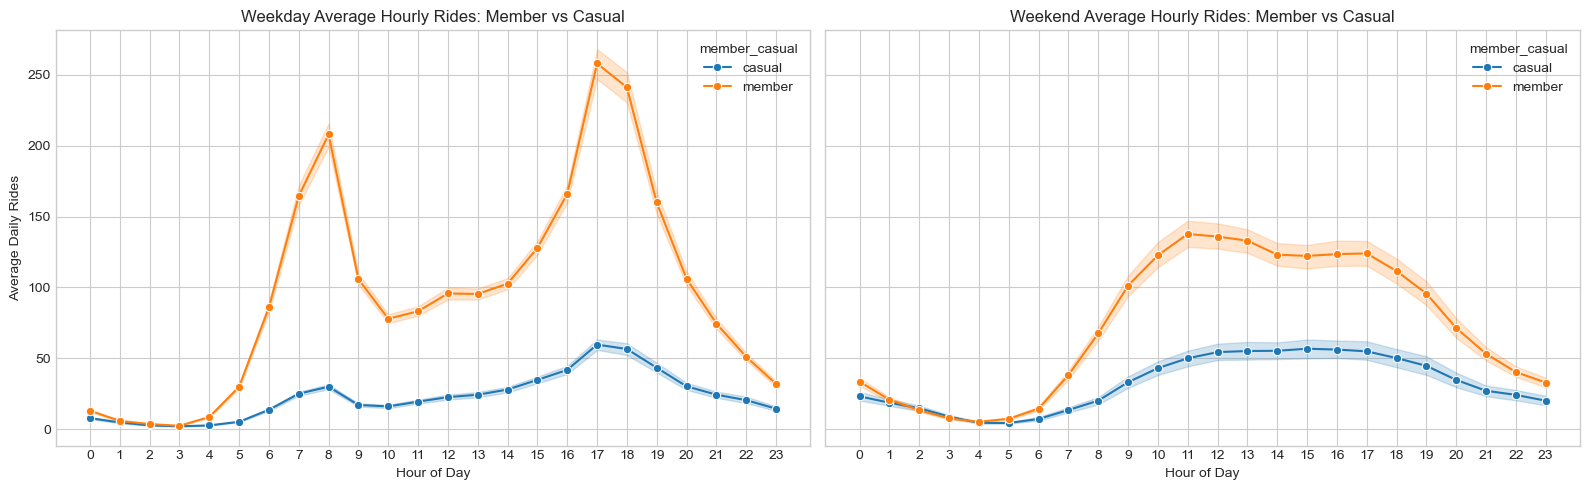

In [22]:
df_bike['weekday'] = df_bike['date'].dt.weekday
df_bike['is_weekend'] = df_bike['weekday'] >= 5

# Calculate the number of rides
hourly_user_df = df_bike.groupby(['date', 'hour', 'is_weekend', 'member_casual']).size().reset_index(name='ride_count')

weekdays_user_hourly = hourly_user_df[~hourly_user_df['is_weekend']].copy()
weekend_user_hourly = hourly_user_df[hourly_user_df['is_weekend']].copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
# Weekday Plot
sns.lineplot(
    data=weekdays_user_hourly,
    x='hour', y='ride_count', hue='member_casual', marker='o', palette=['#1f77b4', '#ff7f0e'], ax=axes[0]
)
axes[0].set_title("Weekday Average Hourly Rides: Member vs Casual")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Daily Rides")
axes[0].set_xticks(range(24))

# Weekend Plot
sns.lineplot(
    data=weekend_user_hourly,
    x='hour', y='ride_count', hue='member_casual', marker='o', palette=['#1f77b4', '#ff7f0e'], ax=axes[1]
)
axes[1].set_title("Weekend Average Hourly Rides: Member vs Casual")
axes[1].set_xlabel("Hour of Day")
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.show()


## Rideable Type Preference
 Investigate if users prefer E-bikes under harsh weather conditions.

/var/folders/8d/m2g6mms109q57d1rj9rk5wlh0000gp/T/ipykernel_32506/820639264.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=daily_eb_wt, x='Wind', y='ebike_prop', palette='Set2')


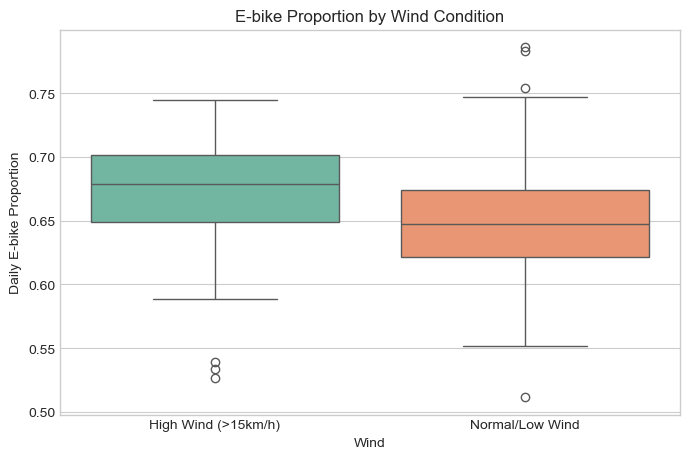

/var/folders/8d/m2g6mms109q57d1rj9rk5wlh0000gp/T/ipykernel_32506/820639264.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=daily_eb_wt, x='Heat', y='ebike_prop', palette='Accent')


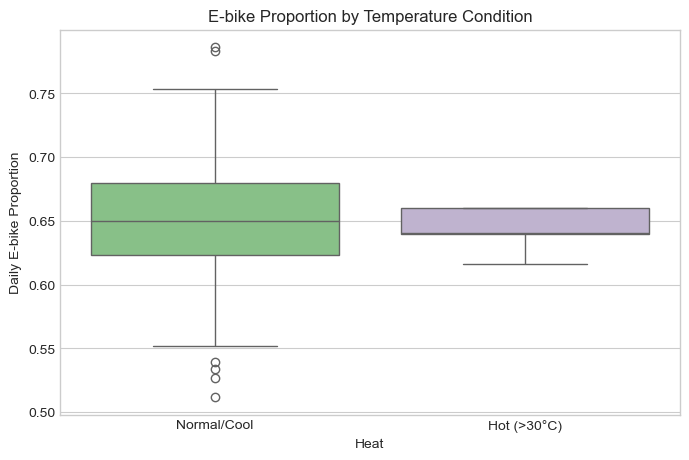

/var/folders/8d/m2g6mms109q57d1rj9rk5wlh0000gp/T/ipykernel_32506/820639264.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=daily_eb_wt, x='Rain', y='ebike_prop', palette='coolwarm')


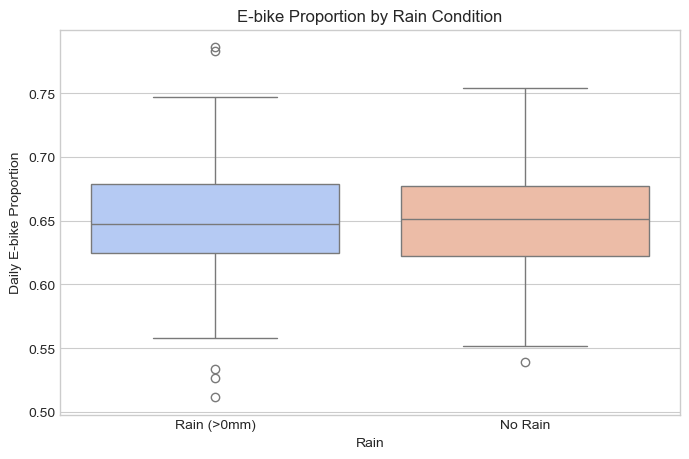

In [24]:
# Calculate daily E-bike usage proportion
df_bike['is_ebike'] = df_bike['rideable_type'] == 'electric_bike'
daily_ebike = df_bike.groupby('date')['is_ebike'].mean().reset_index(name='ebike_prop')

weather_cols = ['date', 'temperature_c', 'wind_speed_kmh', 'precipitation_mm']
daily_eb_wt = pd.merge(daily_ebike, daily_df[weather_cols], on='date')
daily_eb_wt['Wind'] = daily_eb_wt['wind_speed_kmh'].apply(lambda x: 'High Wind (>15km/h)' if x > 15 else 'Normal/Low Wind')
daily_eb_wt['Heat'] = daily_eb_wt['temperature_c'].apply(lambda x: 'Hot (>30°C)' if x > 30 else 'Normal/Cool')
daily_eb_wt['Rain'] = daily_eb_wt['precipitation_mm'].apply(lambda x: 'Rain (>0mm)' if x > 0 else 'No Rain')

#Wind Analysis
plt.figure(figsize=(8, 5))
sns.boxplot(data=daily_eb_wt, x='Wind', y='ebike_prop', palette='Set2')
plt.title("E-bike Proportion by Wind Condition")
plt.ylabel("Daily E-bike Proportion")
plt.show()

#Extreme Heat Analysis
plt.figure(figsize=(8, 5))
sns.boxplot(data=daily_eb_wt, x='Heat', y='ebike_prop', palette='Accent')
plt.title("E-bike Proportion by Temperature Condition")
plt.ylabel("Daily E-bike Proportion")
plt.show()

#Rain Analysis
plt.figure(figsize=(8, 5))
sns.boxplot(data=daily_eb_wt, x='Rain', y='ebike_prop', palette='coolwarm')
plt.title("E-bike Proportion by Rain Condition")
plt.ylabel("Daily E-bike Proportion")
plt.show()